# LABORATORIUM 8 - SIEĆ NEURONOWA

## 8.1 Uczenie i ewaluacja trójwarstwowej sieci neuronowej z ReLu i logistyczną funkcją aktywacji 

In [3]:
import numpy as np
from sklearn.datasets import make_blobs, make_classification, make_moons
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import math
import numpy as np
from sklearn.model_selection import train_test_split
import time


#### Funkcja generująca zbiory danych:

In [42]:
def generate_blobs(n_samples, n_features, random_state, split_data=[0, 2, 4]):
    centers_multi = [
        (-5, 5), (-5, 0), (-5, -5),  
        (5, 5), (5, 0), (5, -5)
    ]
    X_uni, y_uni = make_blobs(n_samples=n_samples, centers=centers_multi, n_features=n_features, random_state=random_state)
    y_uni = np.where(np.isin(y_uni, split_data), 0, 1)
    # y_uni = 2 * y_uni - 1
    return X_uni, y_uni

#### Funckja obliczająca metryki i statystyki:

In [43]:
def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()
    return accuracy, sensitivity, specificity, roc_auc

#### Sieć neuronowa:

In [44]:
class NeuralNetwork:
    def __init__(self, layers_sizes=[2, 5, 5, 2], act_fun='logistic', eta=0.01, max_epochs=1000):
        self.layers_sizes = layers_sizes
        self.n_layers = len(layers_sizes) - 1
        self.eta = eta
        self.act_function = act_fun
        self.max_epochs = max_epochs
        self.weights = []
        for i in range(self.n_layers):
            print(f"Warstwa {i}: {layers_sizes[i]} -> {layers_sizes[i + 1]}")
            weight_matrix = np.random.randn(layers_sizes[i + 1], layers_sizes[i]) * np.sqrt(2 / layers_sizes[i + 1])
            self.weights.append(weight_matrix)
        self.biases = [np.zeros((1, size)) for size in layers_sizes[1:]]

        print(self.weights)
        print(self.biases)

    def logistic(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def logistic_derivative(self, x):
        s = self.logistic(x)
        return s * (1 - s)
        
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return np.where(x > 0, 1, 0)
        
    def activate(self, x):
        if self.act_function == 'logistic':
            return self.logistic(x)
        elif self.act_function == 'relu':
            return self.relu(x)
        
    def activate_derivative(self, x):
        if self.act_function == 'logistic':
            return self.logistic_derivative(x)
        elif self.act_function == 'relu':
            return self.relu_derivative(x)
    
    def forward(self, X):
        activations = [X]
        for i in range(self.n_layers):
            s = np.dot(activations[-1], self.weights[i].T) + self.biases[i]
            res = self.activate(s)
            activations.append(res)
        return activations

    def backward(self, X, y, activations):
        deltas = []
        error = activations[-1] - y  
        delta = error * self.activate_derivative(activations[-1])
        deltas.append(delta)

        for i in range(self.n_layers - 1, 0, -1):
            error = np.dot(deltas[-1], self.weights[i]) 
            delta = error * self.activate_derivative(activations[i])
            deltas.append(delta)

        deltas.reverse()
        return deltas
    
    def adjust_weights(self, X, activations, deltas):
        for i in range(self.n_layers):
            self.weights[i] -= self.eta * np.dot(deltas[i].T, activations[i]) / X.shape[0]
            self.biases[i] -= self.eta * np.sum(deltas[i], axis=0, keepdims=True) / X.shape[0]
    
    def train(self, X, y):
        y = np.eye(self.weights[-1].shape[0])[y] 
        for epoch in range(self.max_epochs):
            activations = self.forward(X)
            deltas = self.backward(X, y, activations)
            self.adjust_weights(X, activations, deltas)

    def predict(self, X):
        activations = self.forward(X)
        # Zwraca indeks neuronu z największą wartością (0 lub 1)
        return np.argmax(activations[-1], axis=1)

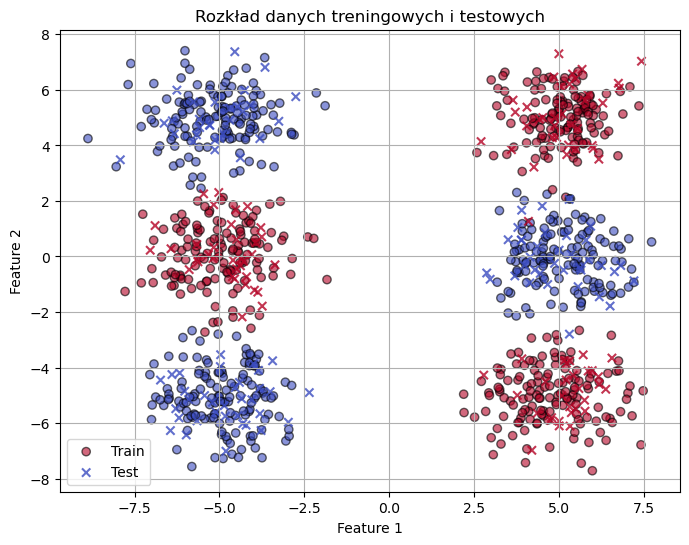

Warstwa 0: 2 -> 5
Warstwa 1: 5 -> 5
Warstwa 2: 5 -> 2
[array([[-0.87932679, -1.26250251],
       [ 0.41701985, -0.78742669],
       [-0.14624504,  0.86459802],
       [ 0.17603952, -0.1227899 ],
       [-1.27405834,  0.0097279 ]]), array([[ 0.73906898,  0.11075776,  0.11410059,  0.67407731,  0.01986754],
       [ 1.45324924, -0.70344428, -0.0647285 , -0.20609219,  0.28636018],
       [ 0.29954447, -0.13798892, -0.37502433, -0.31293029,  0.75941299],
       [ 0.12124861, -0.73403839, -0.07666016, -0.61333056, -0.20199693],
       [ 0.89836681,  0.21171035,  0.00540456,  0.28016694,  0.4206577 ]]), array([[ 1.54373099,  1.17953673, -1.33564703,  0.4947039 , -1.60384406],
       [ 0.04145919,  0.71803497, -0.45283543, -0.69255934,  0.80058363]])]
[array([[0., 0., 0., 0., 0.]]), array([[0., 0., 0., 0., 0.]]), array([[0., 0.]])]
[0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1
 1 1 1 1 1 0 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1
 0 0 1 1 1 0 0

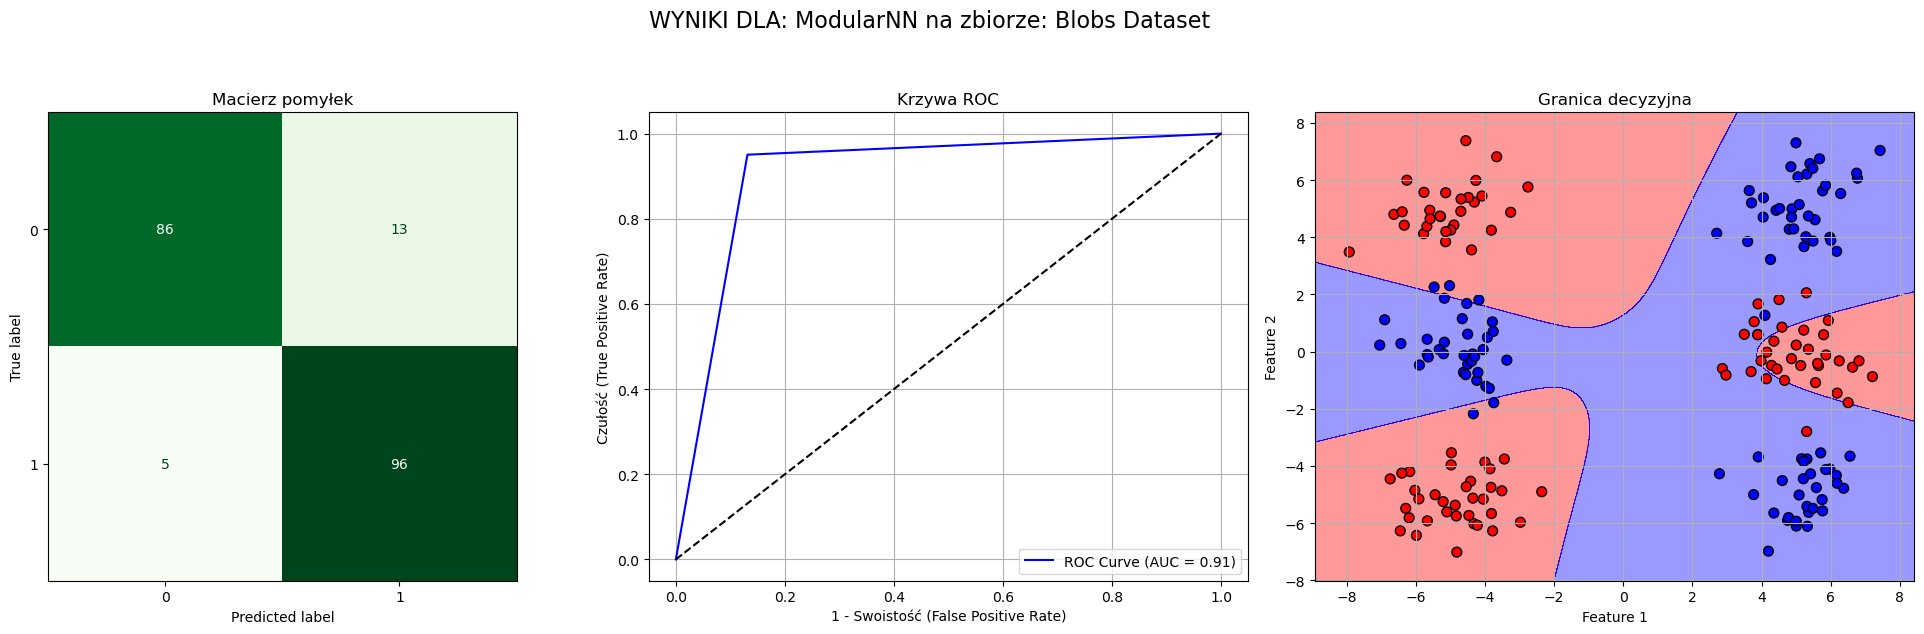

In [47]:
from sklearn.preprocessing import MinMaxScaler

X, y = generate_blobs(n_samples=1000, n_features=2, random_state=259195, split_data=[0, 2, 4])
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=259195)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', label='Train', alpha=0.6, edgecolor='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Test', alpha=0.8)
plt.title('Rozkład danych treningowych i testowych')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

for i in range(1):
    nn = NeuralNetwork(layers_sizes=[2, 5, 5, 2], act_fun='logistic', eta=0.1, max_epochs=5000)
    nn.train(X_train, y_train)
    y_pred = nn.predict(X_test)
print(y_test)
print(y_pred)
acc, sensitivity, specificity, roc_auc = evaluate_classifier(
y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True)

Warstwa 0: 2 -> 5
Warstwa 1: 5 -> 5
Warstwa 2: 5 -> 2
[array([[ 0.003368  ,  0.54608775],
       [ 0.07140712, -0.43698521],
       [-0.27742724, -0.5323613 ],
       [-1.15847217, -0.23775305],
       [-0.0011932 ,  0.79753885]]), array([[ 1.40809786,  0.30356701,  0.50440733, -1.057652  ,  0.71266562],
       [-0.18221722, -0.24044894,  0.92915455,  0.98645098,  0.06112765],
       [ 0.20821295,  0.32116682, -0.35958963, -0.37381408, -0.59043278],
       [ 0.04267374, -1.3172131 , -1.00947077,  0.35936861,  0.35166892],
       [ 0.65240955,  0.48288187, -0.57901294, -1.18049038,  1.00443767]]), array([[-0.41005921,  1.0747757 , -0.50076914,  0.44271394, -0.69999566],
       [-0.03320758,  0.68416349, -1.43674141, -0.41006462, -0.29383599]])]
[array([[0., 0., 0., 0., 0.]]), array([[0., 0., 0., 0., 0.]]), array([[0., 0.]])]
[1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 0 1 1 0 1 0 1 0
 1 1 0 1 1 0 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 0

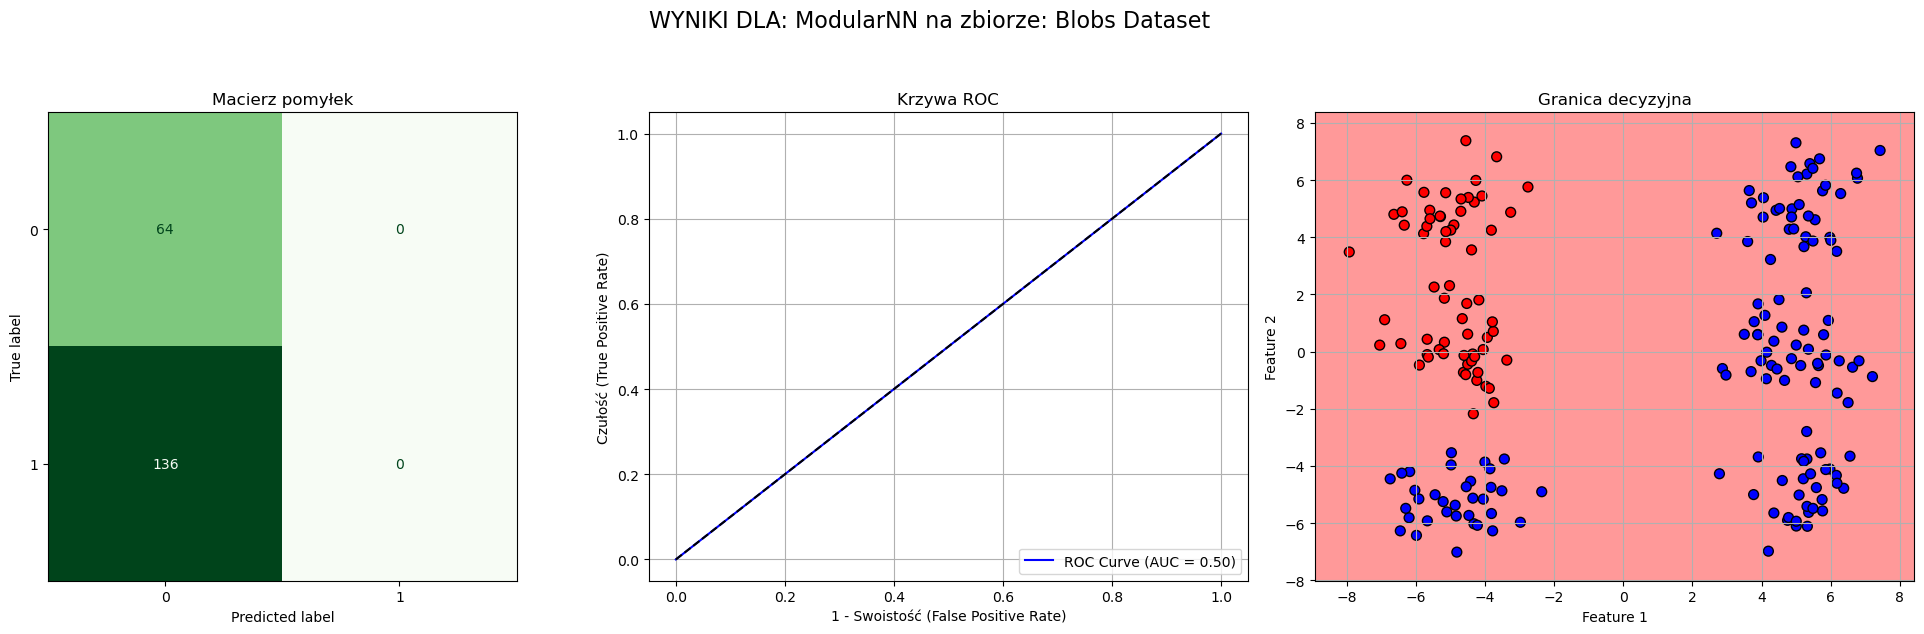

In [46]:
for i in range(1):
    nn = NeuralNetwork(layers_sizes=[2, 5, 5, 2], act_fun='relu', eta=0.1, max_epochs=5000)
    nn.train(X_train, y_train)
    y_pred = nn.predict(X_test)
print(y_test)
print(y_pred)
acc, sensitivity, specificity, roc_auc = evaluate_classifier(
y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True)

#### Przygotowanie zbiorów:

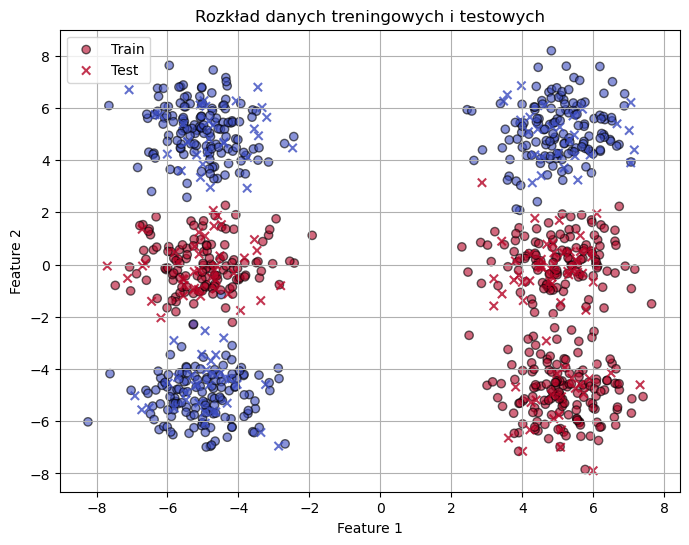

In [8]:
X, y = generate_blobs(n_samples=1000, n_features=2, random_state=42, split_data=[0, 2, 4])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', label='Train', alpha=0.6, edgecolor='k')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Test', alpha=0.8)
plt.title('Rozkład danych treningowych i testowych')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# start = time.time()
# for _ in range(1):
#     nn = ModularNN(
#         layer_sizes=[2, 5, 2],
#         activation_fun='logistic',
#         eta_min=0.01,
#         eta_max=0.1,
#         max_epochs=1000,
#         batch_size=10
#     )
#     nn.fit(X_train, y_train)
#     y_pred = nn.predict(X_test)
# end = time.time()
# print(f"Czas uczenia: {end - start:.2f} sekund")
# acc, sensitivity, specificity, roc_auc = evaluate_classifier(
#     y_test, y_pred, X_test, y_test, nn, "ModularNN", "Blobs Dataset", labels=[0, 1], decision_plot=True
# )
